In [1]:
import torch 
import warnings
import copy
from pathlib import Path
import warnings

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
import numpy as np
import pandas as pd
import torch

from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE, SMAPE, PoissonLoss, QuantileLoss
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import (
    optimize_hyperparameters,
)

import json
import os
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
device = "cpu"
device

c:\Users\PREDATOR\anaconda3\envs\tst_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cpu'

In [2]:
def append_to_json_file(data, file):
    if os.path.exists(file):
        return 
    
    with open(file, 'w', encoding='utf-8') as json_file:
        json.dump(data, json_file, indent=4, ensure_ascii=False)
    print(f"Data saved to {file}")


def preprocess_for_forecasting(df):
    """
    Preprocesses the DataFrame for time series forecasting.
    """

    df_processed = df.copy()

    df_processed['date'] = pd.to_datetime(df_processed['date'])

    df_processed.set_index('date', inplace=True)

    df_processed.sort_index(inplace=True)

    numeric_cols = df_processed.select_dtypes(include=['float64', 'int64']).columns
    df_processed[numeric_cols] = df_processed[numeric_cols].interpolate(method='time')

    df_processed['dayofweek'] = df_processed.index.dayofweek
    df_processed['month'] = df_processed.index.month
    df_processed['year'] = df_processed.index.year
    df_processed['dayofyear'] = df_processed.index.dayofyear
    df_processed['weekofyear'] = df_processed.index.isocalendar().week.astype(int)

    for col in ['total_price_167', 'taux_occupation_167', 'total_price_166', 'taux_occupation_166']:
        if col in df_processed.columns:
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce') 

    if df_processed.isnull().sum().sum() > 0:
        print("Warning: NaNs still present after interpolation. Consider further handling (e.g., ffill/bfill).")
        df_processed.ffill(inplace=True)

    return df_processed


def select_date_range(df, start_date, end_date): 
    """
    Selects a date range from the DataFrame.
    """
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)
    
    df_range = df.loc[start:end]
    
    return df_range


def split_df(df, units=['167', '166']):
    """
    Splits the DataFrame based on the units.
    """
    common_cols = ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear']
    
    if 'date' not in df.columns and df.index.name == 'date':
        df = df.reset_index()
    
    if 'date' in df.columns:
        common_cols = ['date'] + common_cols
    
    df_167 = df[common_cols + [f'total_price_{units[0]}', f'taux_occupation_{units[0]}']]
    
    df_166 = df[common_cols + [f'total_price_{units[1]}', f'taux_occupation_{units[1]}']]

    df_166.set_index('date', inplace=True)
    df_167.set_index('date', inplace=True)
    
    return df_167, df_166

def prepare_and_plot_data(csv_path, start_date, end_date, units=['167', '166']):
    """
    Prepares data from a CSV file, performs preprocessing, selects a date range,
    splits the data by units, and plots the specified metrics.
    """
    df = pd.read_csv(csv_path)
    df = preprocess_for_forecasting(df)
    
    df_range = select_date_range(df, start_date, end_date)
    
    plt.figure(figsize=(20, 15))
    
    plt.subplot(2, 2, 1)
    df.plot(figsize=(15, 5), title=f'Total Price Over Time - Unit {units[0]}', y=f'total_price_{units[0]}', ax=plt.gca())
    
    plt.subplot(2, 2, 2)
    df.plot(figsize=(15, 5), title=f'Total Price Over Time - Unit {units[1]}', y=f'total_price_{units[1]}', ax=plt.gca())
    
    plt.subplot(2, 2, 3)
    df.plot(figsize=(15, 5), title=f'TAUX Over Time - Unit {units[0]}', y=f'taux_occupation_{units[0]}', ax=plt.gca())
    
    plt.subplot(2, 2, 4)
    df.plot(figsize=(15, 5), title=f'TAUX Over Time - Unit {units[1]}', y=f'taux_occupation_{units[1]}', ax=plt.gca())
    
    plt.tight_layout()
    plt.show()
    
    df_unit1, df_unit2 = split_df(df_range, units)
    
    return df_unit1, df_unit2

In [3]:
df = pd.read_csv("../../Data/UnitsFinalCSVData/FinalCSVdata.csv")
df = preprocess_for_forecasting(df)

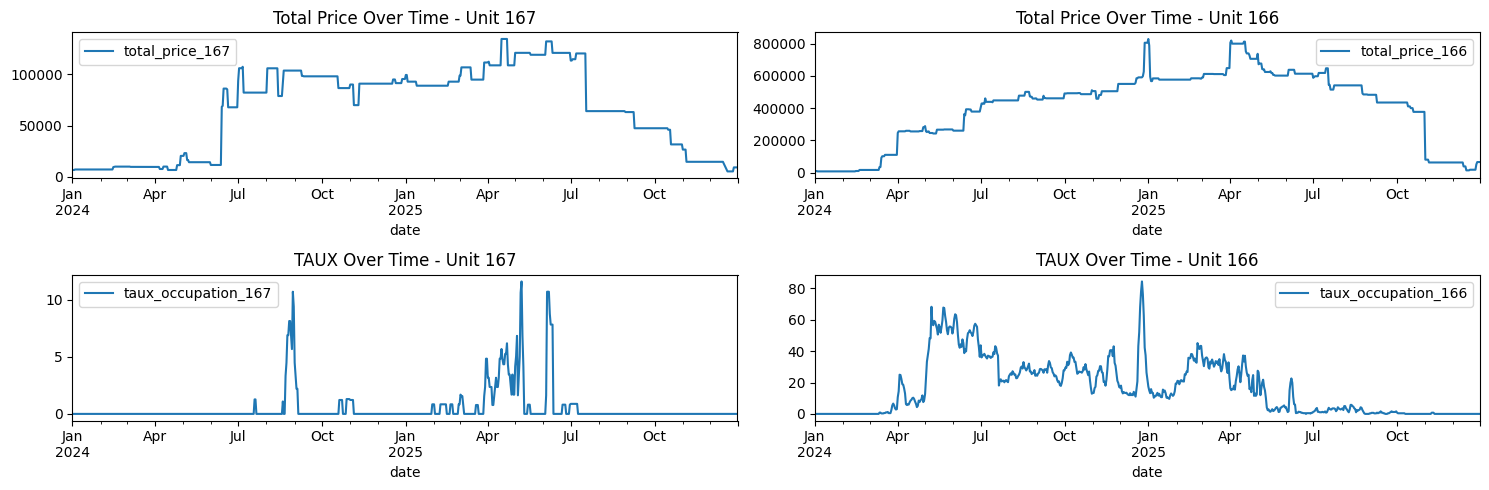

In [4]:
df_167, df_166 = prepare_and_plot_data('../../Data/UnitsFinalCSVData/FinalCSVdata.csv', 
                                       '2024-06-15', '2025-07-15')

In [5]:
df.sample(5)

,total_price_166,taux_occupation_166,total_price_167,taux_occupation_167,dayofweek,month,year,dayofyear,weekofyear
date,,,,,,,,,
2025-04-09,799603.915,28.42,108595.456,2.36,2,4,2025,99,15
2025-09-11,434443.123,0.81,47338.412,0.00,3,9,2025,254,37
2024-04-05,255895.398,22.22,9655.000,0.00,4,4,2024,96,14
2025-07-30,540895.394,3.15,64011.558,0.00,2,7,2025,211,31
2025-07-29,540895.394,3.51,64011.558,0.00,1,7,2025,210,31


In [6]:
df = df.reset_index() # Reset index to make 'date' a column if it's the index

# add time index
df["time_idx"] = df["date"].dt.year * 12 + df["date"].dt.month
df["time_idx"] -= df["time_idx"].min()

# add additional features
df["month"] = df.date.dt.month.astype(str).astype("category")

df.head()

,date,total_price_166,taux_occupation_166,total_price_167,taux_occupation_167,dayofweek,month,year,dayofyear,weekofyear,time_idx
0,2024-01-01,9416.0,0.0,6692.25,0.0,0,1,2024,1,1,0
1,2024-01-02,9416.0,0.0,6692.25,0.0,1,1,2024,2,1,0
2,2024-01-03,9416.0,0.0,6692.25,0.0,2,1,2024,3,1,0
3,2024-01-04,7308.0,0.0,7176.00,0.0,3,1,2024,4,1,0
4,2024-01-05,7308.0,0.0,7176.00,0.0,4,1,2024,5,1,0


In [7]:
df.sample(5)

,date,total_price_166,taux_occupation_166,total_price_167,taux_occupation_167,dayofweek,month,year,dayofyear,weekofyear,time_idx
684,2025-11-15,62681.400,0.00,14654.000,0.00,5,11,2025,319,46,22
439,2025-03-15,610959.099,31.35,94690.712,0.00,5,3,2025,74,11,14
549,2025-07-03,597492.026,2.12,114551.508,0.88,3,7,2025,184,27,18
659,2025-10-21,376531.196,0.00,31598.380,0.00,1,10,2025,294,43,21
420,2025-02-24,584726.371,45.15,92704.012,0.00,0,2,2025,55,9,13


In [8]:
df.shape

(731, 11)

In [9]:
df.columns

Index(['date', 'total_price_166', 'taux_occupation_166', 'total_price_167',
       'taux_occupation_167', 'dayofweek', 'month', 'year', 'dayofyear',
       'weekofyear', 'time_idx'],
      dtype='object')

In [37]:
# ...existing code...
# df.columns

# 1. Reshape data from wide to long format
common_columns = ['date', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'time_idx']

# Data for unit 166
df_166_long = df[common_columns + ['total_price_166', 'taux_occupation_166']].copy()
df_166_long.rename(columns={'total_price_166': 'total_price', 'taux_occupation_166': 'taux_occupation'}, inplace=True)
df_166_long['unit_id'] = '166'

# Data for unit 167
df_167_long = df[common_columns + ['total_price_167', 'taux_occupation_167']].copy()
df_167_long.rename(columns={'total_price_167': 'total_price', 'taux_occupation_167': 'taux_occupation'}, inplace=True)
df_167_long['unit_id'] = '167'

# Concatenate the two dataframes
data_long = pd.concat([df_166_long, df_167_long], ignore_index=True)

# 2. Convert relevant columns to categorical
data_long['unit_id'] = data_long['unit_id'].astype(str).astype("category")
data_long['dayofweek'] = data_long['dayofweek'].astype(str).astype("category")
# 'month' is already categorical from your previous step

# Display a sample of the reshaped data and its info
print("\nInfo of data_long:")
data_long.info()

# 3. Define TimeSeriesDataSet parameters and create datasets
max_prediction_length = 6  # You can adjust this
max_encoder_length = 24   # You can adjust this
training_cutoff = data_long["time_idx"].max() - max_prediction_length

training = TimeSeriesDataSet(
    data_long[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="total_price",
    group_ids=["unit_id"],
    min_encoder_length=max_encoder_length // 2,  # Fixed this line
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=["unit_id"],
    time_varying_known_categoricals=["month", "dayofweek"],
    time_varying_known_reals=["time_idx", "year", "dayofyear", "weekofyear"],
    time_varying_unknown_reals=["total_price", "taux_occupation"],
    target_normalizer=GroupNormalizer(
        groups=["unit_id"], transformation="softplus"
    ),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True
)

validation = TimeSeriesDataSet.from_dataset(
    training, data_long, predict=True, stop_randomization=True
)

# Create dataloaders for model
batch_size = 128  # Adjust as needed
train_dataloader = training.to_dataloader(
    train=True, batch_size=batch_size, num_workers=0 # Set num_workers > 0 for faster loading if not on Windows or if __main__ is protected
)
val_dataloader = validation.to_dataloader(
    train=False, batch_size=batch_size * 10, num_workers=0
)

print(f"\nTraining dataset created with {len(training)} samples.")
print(f"Validation dataset created with {len(validation)} samples.")
print(f"Train dataloader: {train_dataloader}")
print(f"Validation dataloader: {val_dataloader}")


Info of data_long:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             1462 non-null   datetime64[ns]
 1   dayofweek        1462 non-null   category      
 2   month            1462 non-null   category      
 3   year             1462 non-null   int32         
 4   dayofyear        1462 non-null   int32         
 5   weekofyear       1462 non-null   int32         
 6   time_idx         1462 non-null   int32         
 7   total_price      1462 non-null   float64       
 8   taux_occupation  1462 non-null   float64       
 9   unit_id          1462 non-null   category      
dtypes: category(3), datetime64[ns](1), float64(2), int32(4)
memory usage: 62.4 KB

Training dataset created with 666 samples.
Validation dataset created with 2 samples.
Train dataloader: <torch.utils.data.dataloader.DataLoader object at

In [11]:
data_long[data_long['date'] == '2024-06-15']

,date,dayofweek,month,year,dayofyear,weekofyear,time_idx,total_price,taux_occupation,unit_id
166,2024-06-15,5,6,2024,167,24,5,392553.004,39.89,166
897,2024-06-15,5,6,2024,167,24,5,85958.800,0.00,167


In [12]:
pl.seed_everything(42)

trainer = pl.Trainer(
    accelerator="cpu",
    # clipping gradients is a hyperparameter and important to prevent divergance
    # of the gradient for recurrent neural networks
    gradient_clip_val=0.1,
)


tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=32,
    attention_head_size=2,
    dropout=0.15,
    hidden_continuous_size=16,  # Fixed this line
    loss=QuantileLoss(),  # Fixed this line
    optimizer="ranger",
    reduce_on_plateau_patience=4,
)

print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")  # Fixed this line

Seed set to 42
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Number of parameters in network: 84.4k


In [13]:
from lightning.pytorch.loggers import TensorBoardLogger
logger = TensorBoardLogger("../TrainedModels/Testtft")

In [14]:

early_stop_callback = EarlyStopping(
    monitor="val_loss",  # Monitor validation loss
    min_delta=1e-4,      # Minimum change to qualify as an improvement
    patience=10,         # Number of epochs with no improvement after which training will be stopped
    verbose=True,        # Print a message when stopping
    mode="min"           # Stop when the monitored quantity has stopped decreasing
)

lr_logger = LearningRateMonitor(logging_interval='epoch') # Log learning rate every epoch

# Configure the Trainer
trainer = pl.Trainer(
    max_epochs=50,  # Adjust as needed
    accelerator="cpu",
    enable_model_summary=True,
    gradient_clip_val=tft.hparams.gradient_clip_val if hasattr(tft.hparams, 'gradient_clip_val') else 0.1, # Use model's grad clip if defined, else default
    # limit_train_batches=50,  # Uncomment for faster development cycles, comment out for full training
    # limit_val_batches=20,    # Uncomment for faster development cycles
    # fast_dev_run=True,       # Uncomment to run a quick check (1 train, 1 val batch)
    callbacks=[lr_logger, early_stop_callback],
    logger=logger, # Use the logger defined in cell b604b1d9
)

# Train the model
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 109    | train
3  | prescalers                         | ModuleDict                      | 320    | train
4  | static_variable_selection          | VariableSelectionNetwork        | 5.8 K  | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 14.7 K | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 10.4 K | train
7  | static_context_variable_selection  | GatedResidualNetwork            | 4.3 K  | train
8  | static_context_initial_hidden_lstm | GatedResidualNetwork            | 4.3 K  

Epoch 0: 100%|██████████| 5/5 [00:27<00:00,  0.18it/s, v_num=3, train_loss_step=7.1e+4, val_loss=2.35e+5, train_loss_epoch=8.25e+4]

Metric val_loss improved. New best score: 234849.859


Epoch 1: 100%|██████████| 5/5 [00:25<00:00,  0.19it/s, v_num=3, train_loss_step=7.88e+4, val_loss=2.34e+5, train_loss_epoch=8.17e+4]

...

Epoch 48: 100%|██████████| 5/5 [00:26<00:00,  0.19it/s, v_num=3, train_loss_step=5.5e+4, val_loss=2.25e+5, train_loss_epoch=5.44e+4] 

Metric val_loss improved by 97.031 >= min_delta = 0.0001. New best score: 225339.422


Epoch 49: 100%|██████████| 5/5 [00:26<00:00,  0.19it/s, v_num=3, train_loss_step=5.73e+4, val_loss=2.25e+5, train_loss_epoch=5.44e+4]

Metric val_loss improved by 87.875 >= min_delta = 0.0001. New best score: 225251.547
`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 5/5 [00:26<00:00,  0.19it/s, v_num=3, train_loss_step=5.73e+4, val_loss=2.25e+5, train_loss_epoch=5.44e+4]


In [21]:
best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

In [22]:
# calcualte mean absolute error on validation set
predictions = best_tft.predict(
    val_dataloader, return_y=True, trainer_kwargs=dict(accelerator="cpu")
)
MAE()(predictions.output, predictions.y)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


tensor(326977.0938)

In [23]:
def plot_tft_prediction_custom(x_dict, y_pred, idx=0, add_loss_to_title=True):
    """
    Custom function to plot predictions from a Temporal Fusion Transformer model.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Get prediction and actual values
    prediction = y_pred["prediction"][idx].detach().cpu().numpy()
    encoder_target = x_dict["encoder_target"][idx].detach().cpu().numpy()
    decoder_target = x_dict["decoder_target"][idx].detach().cpu().numpy()
    
    # Extract the median prediction (typically middle column)
    median_prediction = prediction[:, 3] if prediction.ndim > 1 else prediction
    
    # Create time indices
    encoder_length = len(encoder_target)
    decoder_length = len(decoder_target)
    time_idx_encoder = list(range(-encoder_length, 0))
    time_idx_decoder = list(range(decoder_length))
    
    # Plot the data
    ax.plot(time_idx_encoder, encoder_target, 'k-', label='Historical Values')
    ax.plot(time_idx_decoder, decoder_target, 'g--', label='Actual Future')
    ax.plot(time_idx_decoder, median_prediction, 'b-', label='Prediction (median)')
    
    # Add vertical line at prediction start
    ax.axvline(x=0, color='r', linestyle='--')
    
    # Calculate and add loss to title if requested
    if add_loss_to_title:
        mse = ((median_prediction - decoder_target) ** 2).mean()
        rmse = mse ** 0.5
        ax.set_title(f"Sample {idx} - RMSE: {rmse:.4f}")
    else:
        ax.set_title(f"Sample {idx}")
    
    # Get unit ID if available
    if "static_categorical" in x_dict:
        try:
            unit_id = x_dict["static_categorical"][idx].item()
            ax.set_title(f"{ax.get_title()} - Unit: {unit_id}")
        except (IndexError, KeyError, AttributeError):
            pass
    
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Total Price")
    ax.legend()
    
    plt.tight_layout()
    return fig

In [24]:
raw_predictions = best_tft.predict(
    val_dataloader, mode="raw", return_x=True, trainer_kwargs=dict(accelerator="cpu")
)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


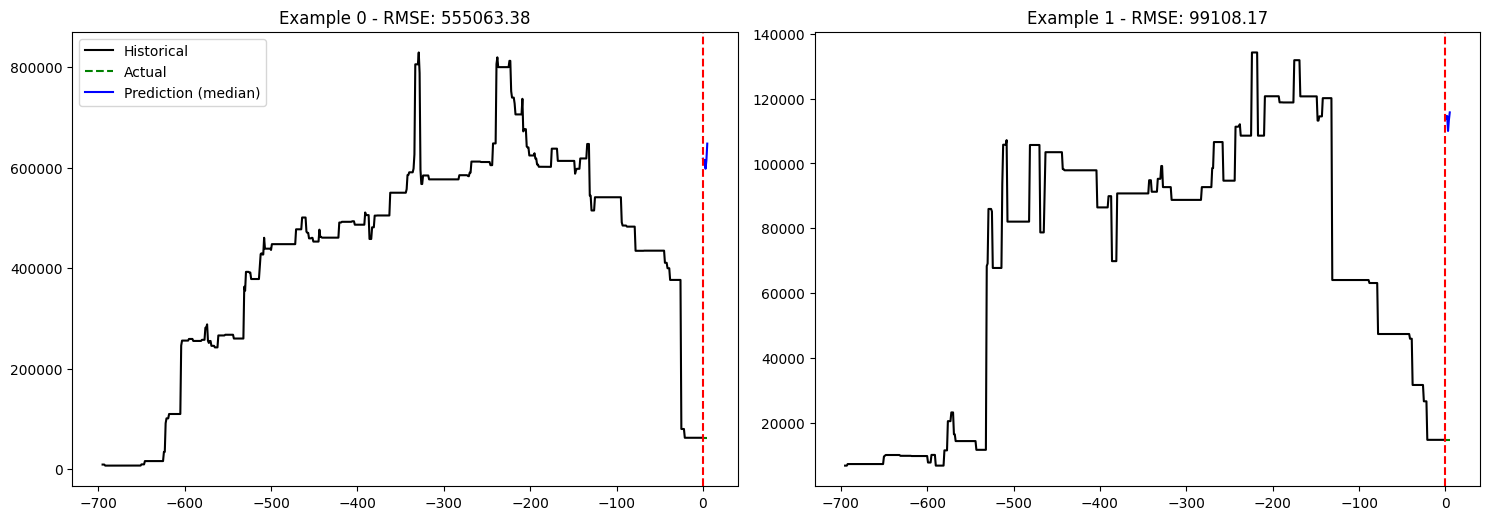

In [29]:
# First, determine how many examples are available
num_examples = len(raw_predictions.output["prediction"])

plt.figure(figsize=(15, 10))
for idx in range(min(4, num_examples)):  # Plot up to 4 examples, but no more than what's available
    plt.subplot(2, 2, idx+1)  # 2 rows, 2 columns
    
    # Get prediction and actual values
    prediction = raw_predictions.output["prediction"][idx].detach().cpu().numpy()
    encoder_target = raw_predictions.x["encoder_target"][idx].detach().cpu().numpy()
    decoder_target = raw_predictions.x["decoder_target"][idx].detach().cpu().numpy()
    
    # Extract the median prediction (50th percentile, typically the middle column)
    # For QuantileLoss, the default quantiles are [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
    # so we want the 4th column (index 3) for the 50th percentile
    median_prediction = prediction[:, 3] if prediction.ndim > 1 else prediction
    
    # Create time indices
    encoder_length = len(encoder_target)
    decoder_length = len(decoder_target)
    time_idx_encoder = list(range(-encoder_length, 0))
    time_idx_decoder = list(range(decoder_length))
    
    # Plot the data
    plt.plot(time_idx_encoder, encoder_target, 'k-', label='Historical')
    plt.plot(time_idx_decoder, decoder_target, 'g--', label='Actual')
    plt.plot(time_idx_decoder, median_prediction, 'b-', label='Prediction (median)')
    
    # Add vertical line at prediction start
    plt.axvline(x=0, color='r', linestyle='--')
    
    # Calculate RMSE using the median prediction
    mse = ((median_prediction - decoder_target) ** 2).mean()
    rmse = mse ** 0.5
    plt.title(f"Example {idx} - RMSE: {rmse:.2f}")
    
    if idx == 0:  # Only add legend to the first plot
        plt.legend()

plt.tight_layout()
plt.show()

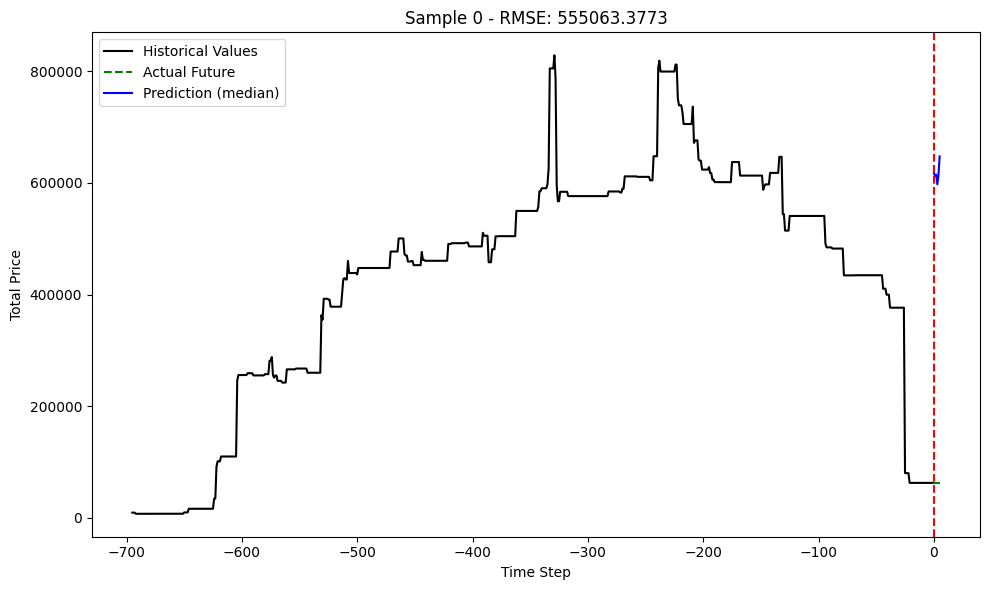

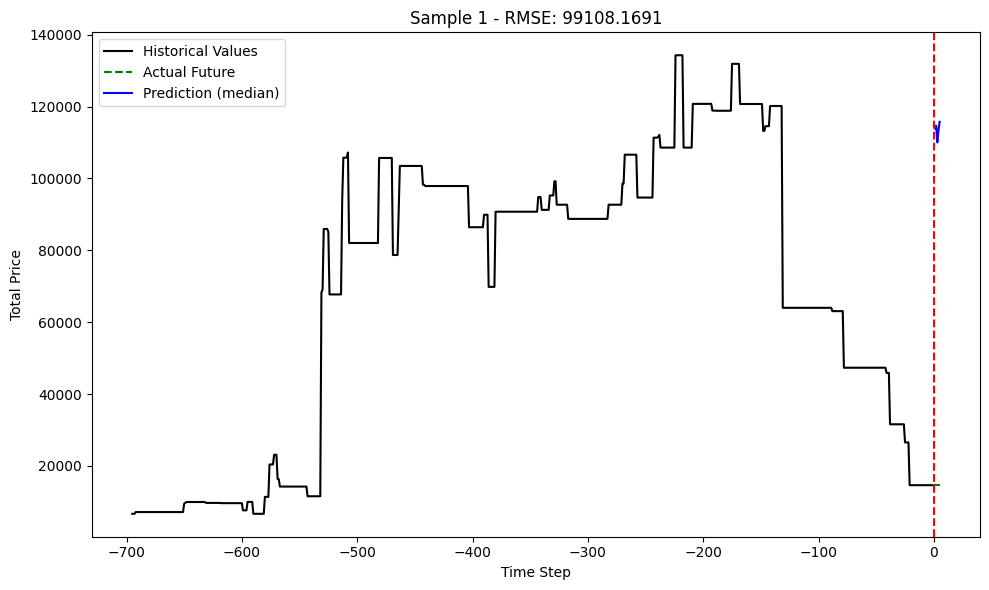

In [27]:
for idx in range(2):  # Plot 10 examples
    fig = plot_tft_prediction_custom(raw_predictions.x, raw_predictions.output, idx=idx)
    plt.show()

In [30]:
raw_predictions = best_tft.predict(
    train_dataloader, mode="raw", return_x=True, trainer_kwargs=dict(accelerator="cpu")
)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


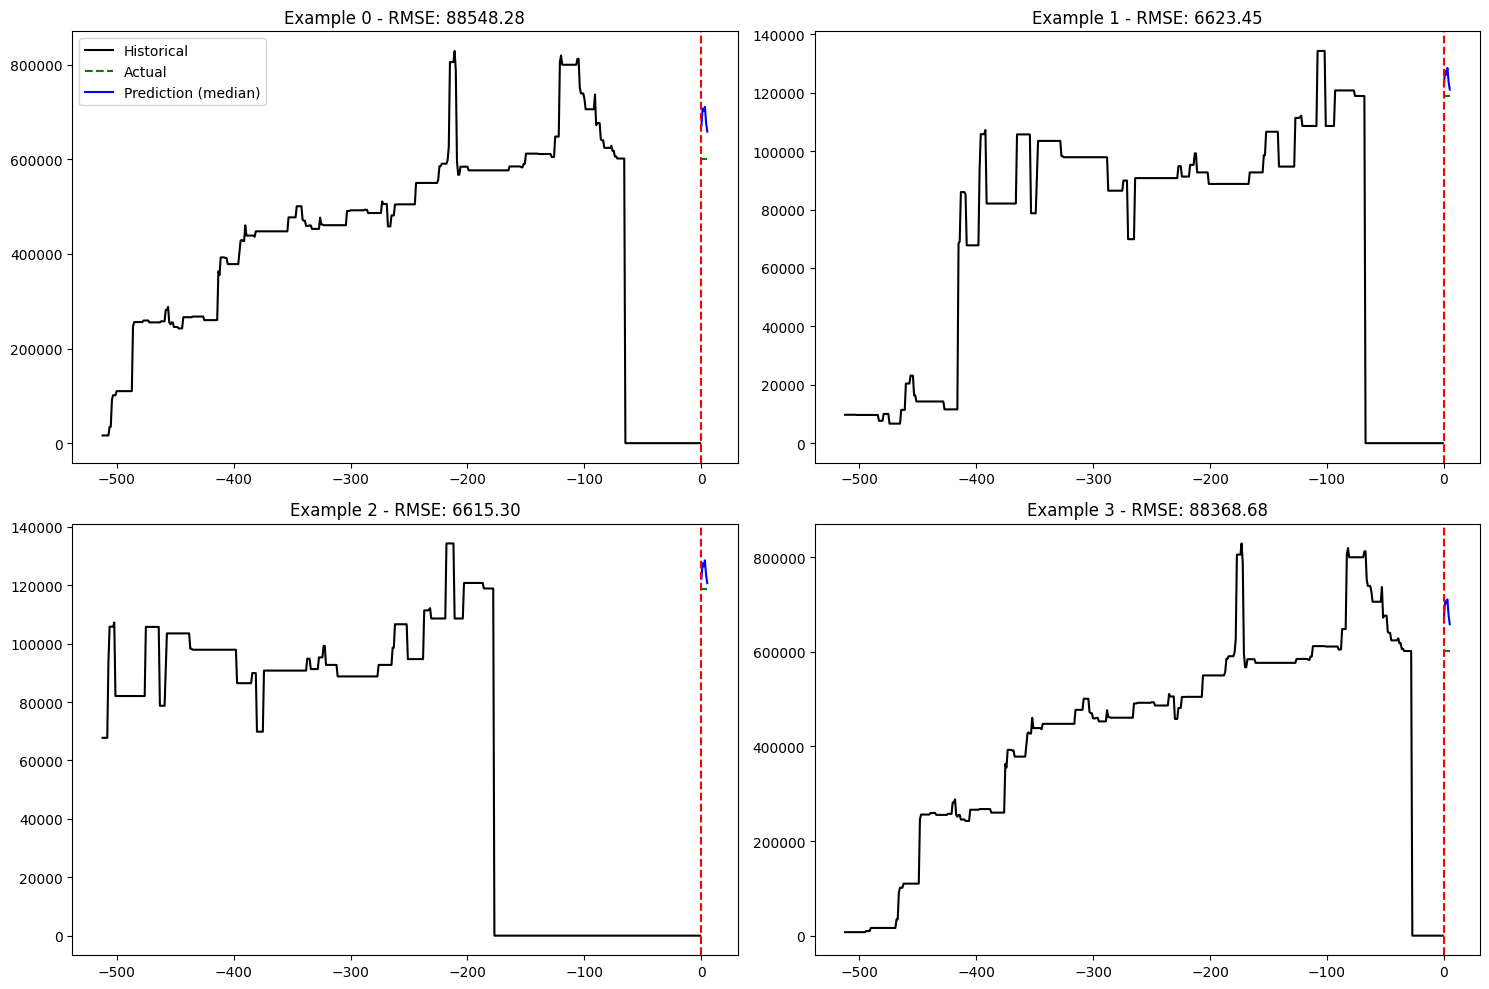

In [31]:
# First, determine how many examples are available
num_examples = len(raw_predictions.output["prediction"])

plt.figure(figsize=(15, 10))
for idx in range(min(4, num_examples)):  # Plot up to 4 examples, but no more than what's available
    plt.subplot(2, 2, idx+1)  # 2 rows, 2 columns
    
    # Get prediction and actual values
    prediction = raw_predictions.output["prediction"][idx].detach().cpu().numpy()
    encoder_target = raw_predictions.x["encoder_target"][idx].detach().cpu().numpy()
    decoder_target = raw_predictions.x["decoder_target"][idx].detach().cpu().numpy()
    
    # Extract the median prediction (50th percentile, typically the middle column)
    # For QuantileLoss, the default quantiles are [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
    # so we want the 4th column (index 3) for the 50th percentile
    median_prediction = prediction[:, 3] if prediction.ndim > 1 else prediction
    
    # Create time indices
    encoder_length = len(encoder_target)
    decoder_length = len(decoder_target)
    time_idx_encoder = list(range(-encoder_length, 0))
    time_idx_decoder = list(range(decoder_length))
    
    # Plot the data
    plt.plot(time_idx_encoder, encoder_target, 'k-', label='Historical')
    plt.plot(time_idx_decoder, decoder_target, 'g--', label='Actual')
    plt.plot(time_idx_decoder, median_prediction, 'b-', label='Prediction (median)')
    
    # Add vertical line at prediction start
    plt.axvline(x=0, color='r', linestyle='--')
    
    # Calculate RMSE using the median prediction
    mse = ((median_prediction - decoder_target) ** 2).mean()
    rmse = mse ** 0.5
    plt.title(f"Example {idx} - RMSE: {rmse:.2f}")
    
    if idx == 0:  # Only add legend to the first plot
        plt.legend()

plt.tight_layout()
plt.show()

In [42]:
def predict_single_date_monthly(
    model,
    training_ds,          # the TimeSeriesDataSet you trained with
    data_long,            # full data in long format
    predict_date: str,    # e.g. "2025-07-16"
    unit_id: str = "166",
):
    predict_date = pd.to_datetime(predict_date)

    # ---------- 1. what is the target time_idx? ----------
    target_time_idx = predict_date.year * 12 + predict_date.month
    enc_len = training_ds.max_encoder_length            # 24
    dec_len = 1                                         # you want 1 step

    # indices needed for encoder & decoder
    needed_time_idx = list(range(target_time_idx - enc_len, target_time_idx + dec_len))

    # ---------- 2. extract those rows ----------
    df_pred = (
        data_long
        .loc[lambda x: (x.unit_id == unit_id) & (x.time_idx.isin(needed_time_idx))]
        .copy()
    )

    # ---------- 3. sanity‑checks ----------
    if df_pred.time_idx.nunique() < enc_len + dec_len:
        raise ValueError(
            f"Need {enc_len} encoder + {dec_len} decoder months "
            f"({enc_len+dec_len} distinct time_idx values). "
            f"Found only {df_pred.time_idx.nunique()}."
        )

    # mark the decoder part (future) with NaN targets
    future_mask = df_pred.time_idx >= target_time_idx
    df_pred.loc[future_mask, "total_price"]     = float("nan")
    df_pred.loc[future_mask, "taux_occupation"] = float("nan")

    # ---------- 4. build dataset/loader ----------
    predict_ds = TimeSeriesDataSet.from_dataset(
        training_ds,
        df_pred,
        predict=True,
        stop_randomization=True,
    )
    loader = predict_ds.to_dataloader(train=False, batch_size=1)

    # ---------- 5. model prediction ----------
    raw = model.predict(loader, mode="raw", return_x=True)
    quantiles = raw.output["prediction"][0][0]   # [q] for one time step
    median = quantiles[3].item()                 # q=0.5

    return median, quantiles, raw


In [43]:
median_price, all_q, _ = predict_single_date_monthly(
    best_tft, training, data_long, "2025-07-16", unit_id="166"
)

print(f"Predicted total_price for 2025‑07‑16 (unit 166): {median_price:.2f}")

ValueError: Need 24 encoder + 1 decoder months (25 distinct time_idx values). Found only 0.